
0: 480x640 (no detections), 407.5ms
Speed: 36.3ms preprocess, 407.5ms inference, 22.8ms postprocess per image at shape (1, 3, 480, 640)


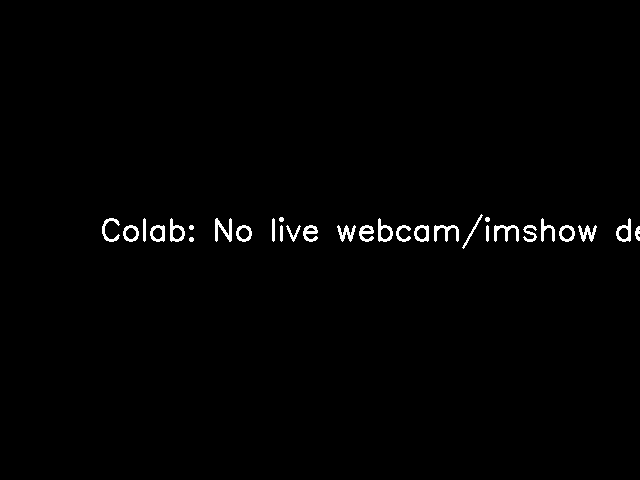

No objects detected in the dummy frame (as expected).


In [3]:
!pip install ultralytics
import cv2
from ultralytics import YOLO
from IPython.display import display, Image
import numpy as np

# Load YOLOv8 model
model = YOLO("yolov8n.pt")


def detect_objects(frame):
    results = model(frame)
    detected_objects = []

    for r in results:
        # Ensure frame is writeable before drawing on it if it's not.
        if not frame.flags['WRITEABLE']:
            frame = frame.copy()

        for box in r.boxes:
            class_id = int(box.cls[0])  # Get class ID
            confidence = box.conf[0].item()  # Confidence score

            if confidence > 0.5:
                label = model.names[class_id]
                detected_objects.append(label)

                # Draw bounding box
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(frame, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    return frame, detected_objects


def main():
    # In Google Colab, cv2.VideoCapture(0) for webcam and cv2.imshow for displaying
    # live video feeds do not work directly due to the lack of a graphical interface.
    # To demonstrate the object detection functionality, we will use a dummy image.

    # Create a dummy black image (e.g., 640x480 pixels)
    # You can replace this with cv2.imread('your_image.jpg') if you upload an image.
    dummy_frame = np.zeros((480, 640, 3), dtype=np.uint8)
    cv2.putText(dummy_frame, "Colab: No live webcam/imshow demo", (100, 240), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

    # Process the dummy frame
    processed_frame, detected_objects = detect_objects(dummy_frame)

    # Display the processed frame using IPython.display
    # Convert BGR to RGB for correct display (OpenCV uses BGR, browser expects RGB)
    processed_frame_rgb = cv2.cvtColor(processed_frame, cv2.COLOR_BGR2RGB)
    _, encoded_img = cv2.imencode('.png', processed_frame_rgb)
    display(Image(data=encoded_img.tobytes()))

    if detected_objects:
        print("Detected objects:", detected_objects)
    else:
        print("No objects detected in the dummy frame (as expected).")

    # The original loop for live webcam feed and cv2.imshow is commented out
    # because it causes errors in Colab's headless environment.
    # cap = cv2.VideoCapture(0)  # Open webcam
    # while True:
    #     ret, frame = cap.read()
    #     if not ret:
    #         break
    #     frame, detected_objects = detect_objects(frame)
    #     cv2.imshow("AI Vision", frame) # This causes the error
    #     if detected_objects:
    #         print("Detected objects:", detected_objects)
    #     key = cv2.waitKey(1) & 0xFF
    #     if key == ord('q'):
    #         break
    # cap.release()
    # cv2.destroyAllWindows() # This causes the error


if __name__ == "__main__":
    main()
